In [ ]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from geope.jax import get_jacobian_propagator
from geope.utils import construct_full_pauli_basis, qft_unitary
from geope.jax import logm_unitary

import numpy as np
import time

from scipy.optimize import curve_fit

In [2]:
def make_basis(n: int) -> jnp.ndarray:
    """Full ``n``-qubit Pauli basis as a ``(K, d, d)`` array.

    ``K = 4**n - 1`` (identity excluded) and ``d = 2**n``.
    """
    return jnp.asarray(construct_full_pauli_basis(n).basis)


def make_params(n_steps: int, K: int, key: jax.Array) -> jnp.ndarray:
    """Random ``(n_steps, K)`` parameter array in complex128.

    Inputs are complex because the autodiff Jacobians use
    ``holomorphic=True`` and the manual path also expects complex
    coefficients.
    """
    return jax.random.normal(key, (n_steps, K)).astype(jnp.complex128)


def warm(fn, *args):
    """Force compilation and return a device-ready result.

    Used both to warm up a function before timing and to materialise a
    result for the correctness guards.
    """
    return jax.block_until_ready(fn(*args))


def _setup(n, n_steps):
    basis = make_basis(n)
    K = basis.shape[0]
    params = make_params(n_steps, K, jax.random.key(0))
    return basis, params


def test_jacobian_propagator_exec(n, n_steps):
    basis, params = _setup(n, n_steps)
    fn = get_jacobian_propagator(basis)
    return fn, params

In [3]:
def run_rounds(n, n_steps, rounds=5, warmup_rounds=10):
    fn, params = test_jacobian_propagator_exec(n, n_steps)
    start = time.time()
    jax.block_until_ready(fn(params))
    stop = time.time()
    print(f"JIT time: {stop-start}[s]")
    timings = []
    for r in range(warmup_rounds + rounds):
        if r > warmup_rounds:
            start = time.time()
            jax.block_until_ready(fn(params))
            stop = time.time()
            print(f"Eval time: {stop-start}[s]")
            timings.append(stop - start)
    return timings

In [4]:
def _setup_logm(n):
    """The geodesic step's argument ``U^dagger U_T`` for an ``n``-qubit problem.

    ``U`` is a random-Hermitian-generated unitary standing in for the current
    iterate and ``U_T`` is the QFT target, so the spectrum matches what the
    optimiser really encounters rather than that of a bare random unitary.
    """
    d = 2**n
    rng = np.random.default_rng(n)
    H = rng.standard_normal((d, d)) + 1j * rng.standard_normal((d, d))
    H = (H + H.conj().T) / 2
    U = jax.scipy.linalg.expm(1j * 0.3 * jnp.asarray(H))
    target = jnp.asarray(qft_unitary(n))
    return U.conj().T @ target


def run_round_logm(n, rounds=5, warmup_rounds=10):
    U = _setup_logm(n)
    print(U.shape)
    KEY = jax.random.key(0)

    fn_logm = jax.jit(lambda x: logm_unitary(x, KEY))
    warm(fn_logm, U)
    start = time.time()
    jax.block_until_ready(fn_logm(U))
    stop = time.time()
    print(f"JIT time: {stop-start}[s]")
    timings = []
    for r in range(warmup_rounds + rounds):
        if r > warmup_rounds:
            start = time.time()
            jax.block_until_ready(fn_logm(U))
            stop = time.time()
            print(f"Eval time: {stop-start}[s]")
            timings.append(stop - start)
    return timings

In [5]:
n = 2
n_steps_grid = [5, 10, 25, 50, 100, 250, 500, 1000]
timings = []
for n_steps in n_steps_grid:
    timings_per_n_steps = run_rounds(n, n_steps)
    timings.append(timings_per_n_steps)

timing_logm = run_round_logm(2)

JIT time: 0.32906103134155273[s]
Eval time: 0.00020599365234375[s]
Eval time: 0.0001590251922607422[s]
Eval time: 0.00013303756713867188[s]
Eval time: 0.0001480579376220703[s]
JIT time: 0.21401619911193848[s]
Eval time: 0.0002770423889160156[s]
Eval time: 0.0002377033233642578[s]
Eval time: 0.0002491474151611328[s]
Eval time: 0.0002560615539550781[s]
JIT time: 0.20875215530395508[s]
Eval time: 0.0005121231079101562[s]
Eval time: 0.00044536590576171875[s]
Eval time: 0.0004057884216308594[s]
Eval time: 0.0004229545593261719[s]
JIT time: 0.24877500534057617[s]
Eval time: 0.0008461475372314453[s]
Eval time: 0.0008280277252197266[s]
Eval time: 0.0008609294891357422[s]
Eval time: 0.0007932186126708984[s]
JIT time: 0.21179890632629395[s]
Eval time: 0.0014681816101074219[s]
Eval time: 0.0013549327850341797[s]
Eval time: 0.001444101333618164[s]
Eval time: 0.0014820098876953125[s]
JIT time: 0.22479891777038574[s]
Eval time: 0.003126859664916992[s]
Eval time: 0.0032889842987060547[s]
Eval time: 0

/var/folders/m4/hkhn64pj5x9_xxq4wkncth480000gp/T/ipykernel_61655/2798284273.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  coeffs, _ = curve_fit(scaling_jac, np.log(xdata), np.log(ydata))


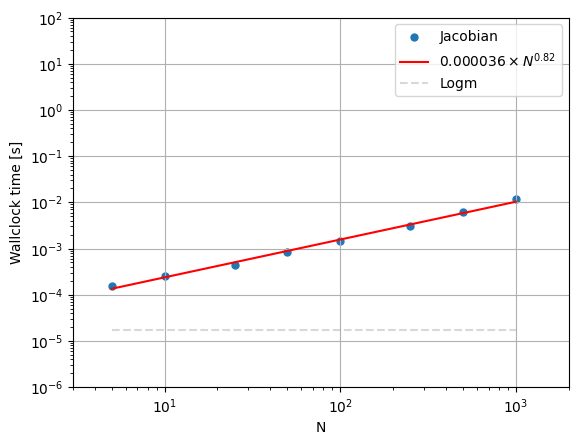

In [ ]:

timings_np = np.array(timings)

def scaling_jac(x, a, b,c):
    #ax**b -> log(a x**b) = log(a) + b * log(x)
    val = a + x*b 
    return val


xdata = n_steps_grid
ydata = np.median(timings_np, axis=1)
coeffs, _ = curve_fit(scaling_jac, np.log(xdata), np.log(ydata))
a_fit, b_fit, c_fit = coeffs

plt.scatter(xdata, ydata, label='Jacobian',marker='.', s=100)
plt.plot(xdata, np.exp(scaling_jac(np.log(xdata), *coeffs)),label=rf"${np.exp(a_fit):1.6f}\times N^{{{b_fit:1.2f}}}$", color='red')
plt.ylabel("Wallclock time [s]")
plt.xlabel("L")
plt.yscale("log")
plt.xscale("log")
plt.grid()
plt.ylim(1e-6, 1e2)
plt.xlim(3, 2e3)

plt.hlines(
    np.median(timing_logm),
    n_steps_grid[0],
    n_steps_grid[-1],
    alpha=0.3,
    linestyle="dashed",
    color='gray',
    label='Logm'
)
plt.legend()

In [25]:
n_log_steps_grid = np.array([i for i in range(2,11)])
timings_logm = []
for n_steps in n_log_steps_grid:
    print(n_steps)
    timings_logm_per_n_steps = run_round_logm(n_steps)
    timings_logm.append(timings_logm_per_n_steps)
timings_log_np = np.array(timings_logm)

2
(4, 4)
JIT time: 3.075599670410156e-05[s]
Eval time: 1.9073486328125e-05[s]
Eval time: 1.5735626220703125e-05[s]
Eval time: 1.5974044799804688e-05[s]
Eval time: 1.4781951904296875e-05[s]
3
(8, 8)
JIT time: 9.202957153320312e-05[s]
Eval time: 6.580352783203125e-05[s]
Eval time: 6.29425048828125e-05[s]
Eval time: 5.817413330078125e-05[s]
Eval time: 5.6743621826171875e-05[s]
4
(16, 16)
JIT time: 0.0001499652862548828[s]
Eval time: 0.00013208389282226562[s]
Eval time: 0.00014781951904296875[s]
Eval time: 0.00015401840209960938[s]
Eval time: 0.00013327598571777344[s]
5
(32, 32)
JIT time: 0.0005619525909423828[s]
Eval time: 0.0007419586181640625[s]
Eval time: 0.0006990432739257812[s]
Eval time: 0.0005710124969482422[s]
Eval time: 0.0006551742553710938[s]
6
(64, 64)
JIT time: 0.003442049026489258[s]
Eval time: 0.003529071807861328[s]
Eval time: 0.0033431053161621094[s]
Eval time: 0.003412961959838867[s]
Eval time: 0.0033817291259765625[s]
7
(128, 128)
JIT time: 0.029176950454711914[s]
Eval 

/var/folders/m4/hkhn64pj5x9_xxq4wkncth480000gp/T/ipykernel_61655/1198427730.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  coeffs, _ = curve_fit(scaling_logm, np.log(xdata), np.log(ydata))


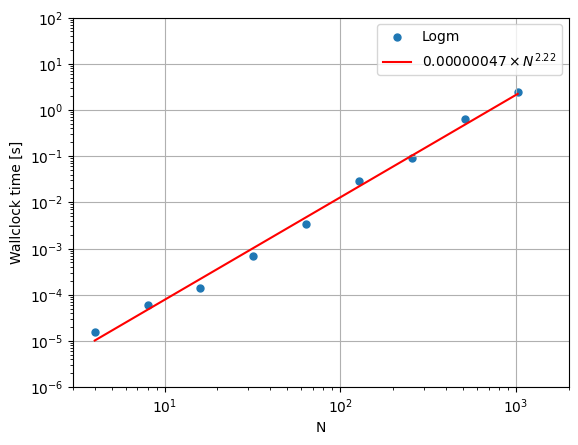

In [45]:
def scaling_logm(x, a, b, c):
    # ax**b -> log(a x**b) = log(a) + b * log(x)
    val = a + x * b
    return val


xdata = 2**n_log_steps_grid
ydata = np.median(timings_log_np, axis=1)
coeffs, _ = curve_fit(scaling_logm, np.log(xdata), np.log(ydata))
a_fit, b_fit, c_fit = coeffs
plt.scatter(xdata, ydata, label="Logm", marker=".", s=100)
plt.plot(
    xdata,
    np.exp(scaling_logm(np.log(xdata), *coeffs)),
    label=rf"${np.exp(a_fit):1.8f}\times N^{{{b_fit:1.2f}}}$",
    color="red",
)
plt.ylabel("Wallclock time [s]")
plt.xlabel("N")
plt.yscale("log")
plt.xscale("log")
plt.grid()
plt.ylim(1e-6, 1e2)
plt.xlim(3, 2e3)

plt.legend()